In [29]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        print("Kütüphaneler Yüklendi")

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv
Kütüphaneler Yüklendi


In [30]:

warnings.filterwarnings("ignore")

df = pd.read_csv("/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv")
print(df.shape)
df.head()

(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [31]:
# Eksik veri analizi
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Eksik Sayı": missing, "Eksik Oran (%)": missing_pct})
missing_df = missing_df[missing_df["Eksik Sayı"] > 0].sort_values("Eksik Sayı", ascending=False)
print(missing_df)

            Eksik Sayı  Eksik Oran (%)
director          2634           29.91
country            831            9.44
cast               825            9.37
date_added          10            0.11
rating               4            0.05
duration             3            0.03


In [32]:
# Eksik verileri doldur
df["director"].fillna("Bilinmiyor", inplace=True)
df["cast"].fillna("Bilinmiyor", inplace=True)
df["country"].fillna("Bilinmiyor", inplace=True)
df["rating"].fillna(df["rating"].mode()[0], inplace=True)
df["date_added"].fillna("Bilinmiyor", inplace=True)
df.dropna(subset=["duration"], inplace=True)

# Yeni sütunlar
df["year_added"] = pd.to_numeric(df["date_added"].str.strip().str[-4:], errors="coerce")
df["duration_val"] = df["duration"].str.extract(r"(\d+)").astype(float)

print("Temizleme sonrası eksik değer:")
print(df.isnull().sum())
print("\nYeni shape:", df.shape)

Temizleme sonrası eksik değer:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added       0
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      10
duration_val     0
dtype: int64

Yeni shape: (8804, 14)


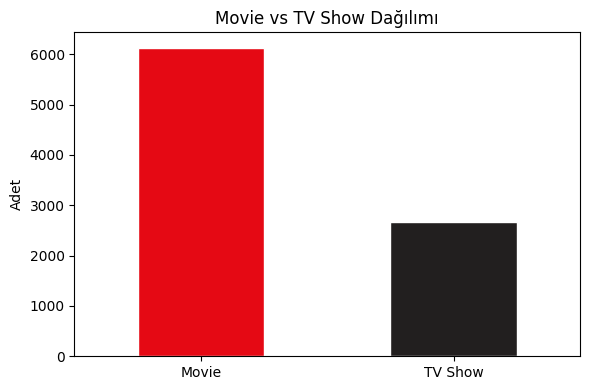

In [33]:
# 1. Hedef değişken dağılımı
plt.figure(figsize=(6,4))
df["type"].value_counts().plot(kind="bar", color=["#e50914","#221f1f"], edgecolor="white")
plt.title("Movie vs TV Show Dağılımı")
plt.xlabel("")
plt.ylabel("Adet")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

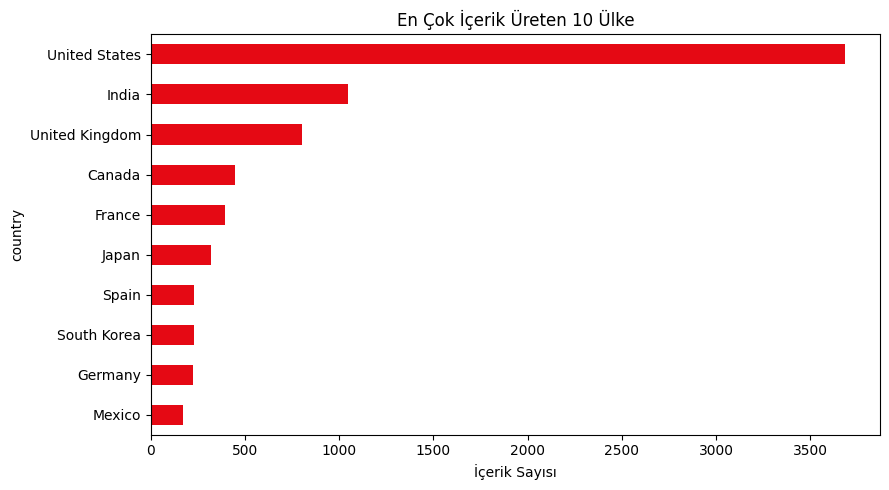

In [34]:
# En çok içerik üreten 10 ülke
top_countries = (df[df["country"] != "Bilinmiyor"]["country"]
                 .str.split(", ").explode()
                 .value_counts().head(10))

plt.figure(figsize=(9,5))
top_countries.sort_values().plot(kind="barh", color="#e50914")
plt.title("En Çok İçerik Üreten 10 Ülke")
plt.xlabel("İçerik Sayısı")
plt.tight_layout()
plt.show()

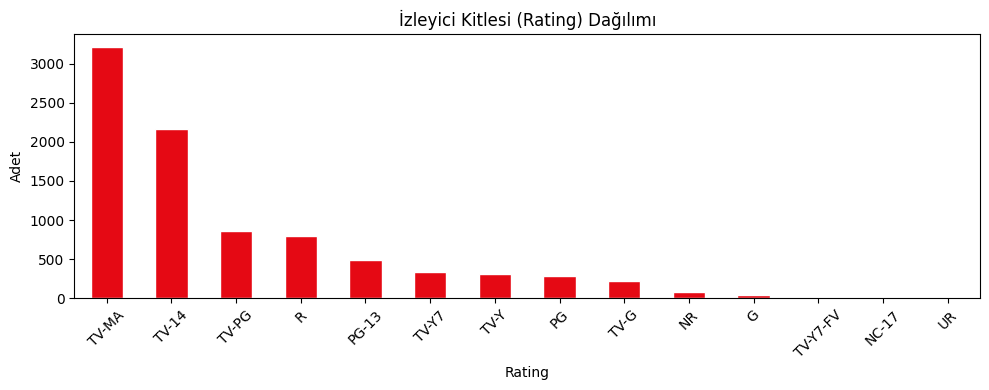

In [35]:
# Rating dağılımı
plt.figure(figsize=(10,4))
df["rating"].value_counts().plot(kind="bar", color="#e50914", edgecolor="white")
plt.title("İzleyici Kitlesi (Rating) Dağılımı")
plt.xlabel("Rating")
plt.ylabel("Adet")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# BÖLÜM 3 - MODEL KURMA
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Hedef değişken: type (Movie=1, TV Show=0)
df["type_label"] = (df["type"] == "Movie").astype(int)

# Kategorik özellikleri sayıya çevir
le_rating = LabelEncoder()
df["rating_enc"] = le_rating.fit_transform(df["rating"])

# Türkçe: Kaç genre var?
df["genre_count"] = df["listed_in"].str.split(",").apply(len)

# Kullanılacak özellikler
features = ["release_year", "duration_val", "genre_count", "rating_enc"]
target = "type_label"

# Eksik kalan satırları düşür
model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

# Eğitim / Test ayrımı (%80 eğitim, %20 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)
print("Hedef dağılım:\n", y.value_counts())

Eğitim seti: (7043, 4)
Test seti: (1761, 4)
Hedef dağılım:
 type_label
1    6128
0    2676
Name: count, dtype: int64


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Model kur ve eğit
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Tahmin
dt_pred = dt_model.predict(X_test)

# Sonuçlar
print("=" * 40)
print("KARAR AĞACI SONUÇLARI")
print("=" * 40)
print(f"Accuracy (Doğruluk): {accuracy_score(y_test, dt_pred):.4f}")
print()
print(classification_report(y_test, dt_pred, target_names=["TV Show", "Movie"]))

KARAR AĞACI SONUÇLARI
Accuracy (Doğruluk): 0.9983

              precision    recall  f1-score   support

     TV Show       0.99      1.00      1.00       566
       Movie       1.00      1.00      1.00      1195

    accuracy                           1.00      1761
   macro avg       1.00      1.00      1.00      1761
weighted avg       1.00      1.00      1.00      1761



In [38]:
from sklearn.ensemble import RandomForestClassifier

# Model kur ve eğit
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Tahmin
rf_pred = rf_model.predict(X_test)

# Sonuçlar
print("=" * 40)
print("RANDOM FOREST SONUÇLARI")
print("=" * 40)
print(f"Accuracy (Doğruluk): {accuracy_score(y_test, rf_pred):.4f}")
print()
print(classification_report(y_test, rf_pred, target_names=["TV Show", "Movie"]))

RANDOM FOREST SONUÇLARI
Accuracy (Doğruluk): 0.9983

              precision    recall  f1-score   support

     TV Show       0.99      1.00      1.00       566
       Movie       1.00      1.00      1.00      1195

    accuracy                           1.00      1761
   macro avg       1.00      1.00      1.00      1761
weighted avg       1.00      1.00      1.00      1761



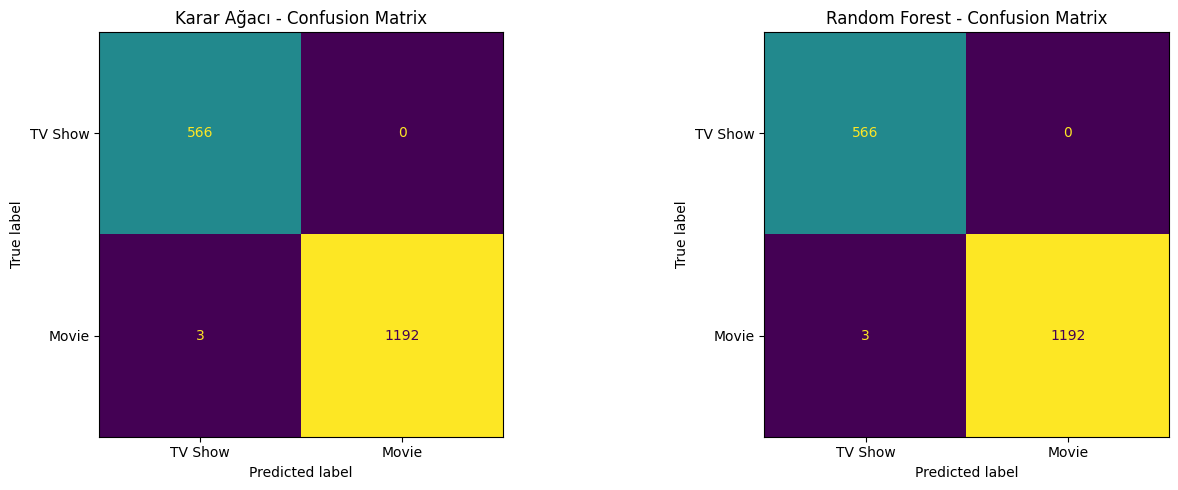

In [39]:
# ============================================================
# BÖLÜM 4 - MODEL DEĞERLENDİRME
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Karar Ağacı Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_pred)
ConfusionMatrixDisplay(cm_dt, display_labels=["TV Show", "Movie"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Karar Ağacı - Confusion Matrix")

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=["TV Show", "Movie"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest - Confusion Matrix")

plt.tight_layout()
plt.show()

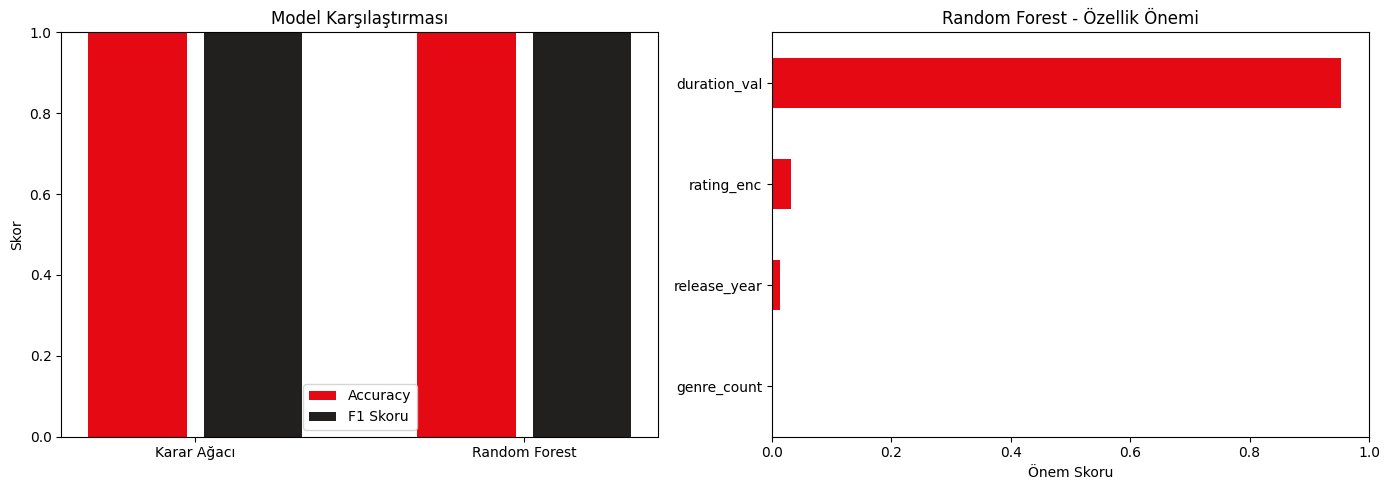


📋 ÖZET TABLO
Model                  Accuracy   F1 Skoru
------------------------------------------
Karar Ağacı              0.9983     0.9987
Random Forest            0.9983     0.9987


In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Metrikleri karşılaştır
models = ["Karar Ağacı", "Random Forest"]
accuracies = [
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]
f1_scores = [
    f1_score(y_test, dt_pred),
    f1_score(y_test, rf_pred)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy & F1 karşılaştırması
x = range(len(models))
axes[0].bar(x, accuracies, width=0.3, label="Accuracy", color="#e50914")
axes[0].bar([i + 0.35 for i in x], f1_scores, width=0.3, label="F1 Skoru", color="#221f1f")
axes[0].set_xticks([i + 0.175 for i in x])
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1)
axes[0].set_title("Model Karşılaştırması")
axes[0].legend()
axes[0].set_ylabel("Skor")

# Feature Importance (Random Forest)
importances = pd.Series(rf_model.feature_importances_, index=features)
importances.sort_values().plot(kind="barh", color="#e50914", ax=axes[1])
axes[1].set_title("Random Forest - Özellik Önemi")
axes[1].set_xlabel("Önem Skoru")

plt.tight_layout()
plt.show()

# Özet tablo
print("\n📋 ÖZET TABLO")
print(f"{'Model':<20} {'Accuracy':>10} {'F1 Skoru':>10}")
print("-" * 42)
for m, a, f in zip(models, accuracies, f1_scores):
    print(f"{m:<20} {a:>10.4f} {f:>10.4f}")